# Laboratorio 2 — Deep Learning (LSTM) · Series de Tiempo
### CC3084 Data Science · UVG · Semestre II 2026

**Avance (pasaporte) — Ejercicio 1.** Se construyen y tunean **modelos LSTM** para predecir
dos de las series de tiempo del Laboratorio 1 y se comparan contra el mejor modelo clásico
(ARIMA/SARIMA, Holt-Winters, …) obtenido en ese laboratorio.

**Series usadas** (mismas definiciones y mismos conjuntos train/test que en el Lab 1):

| Serie | Definición | Transformación |
|-------|-----------|----------------|
| **Total** | `Turista + Excursionista`, agregado mensual | `log` |
| **Aérea** | Vía de ingreso *Aérea* (`Turista + Excursionista`) | `log` |

**Qué contiene este avance**
1. Reconstrucción de las dos series y **partición 70/30 idéntica** a la del Lab 1.
2. Al menos **2 modelos LSTM con configuraciones distintas** por serie + **tuneo de hiperparámetros**.
3. Selección del mejor modelo, **predicción** sobre el horizonte de prueba y **comparación** con el
   mejor modelo del Lab 1.

> Datos de uso exclusivamente académico (ingreso de viajeros internacionales a Guatemala, ene-2009 a jun-2026).

## 0. Instalación de dependencias
Si te falta alguna librería, **descomenta y ejecuta** la siguiente celda. El notebook está pensado
para correr en un entorno con **Python 3.13** (TensorFlow aún no publica *wheels* para 3.14).

In [36]:
# %pip install tensorflow pandas numpy scikit-learn matplotlib seaborn statsmodels openpyxl

In [37]:
import os, random, warnings
warnings.filterwarnings("ignore")
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # silencia los mensajes informativos de TensorFlow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
print("Librerías base cargadas.")

Librerías base cargadas.


## 1. Carga de datos
Se usa la misma base del Laboratorio 1 (`Base_Migracion_2009-2026jun.xlsx`, hoja `Datos`) y se
construye el índice temporal mensual (`freq='MS'`) combinando `Año` y `Mes cod`.

In [38]:
RUTAS = [Path("data/raw/Base_Migracion_2009-2026jun.xlsx"),
         Path("../data/raw/Base_Migracion_2009-2026jun.xlsx")]
ARCHIVO = next((r for r in RUTAS if r.exists()), None)
if ARCHIVO is None:
    raise FileNotFoundError("No se encontró data/raw/Base_Migracion_2009-2026jun.xlsx")

df = pd.read_excel(ARCHIVO, sheet_name="Datos")
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))
print(f"Filas: {df.shape[0]:,} | Rango: {df['Fecha'].min().date()} -> {df['Fecha'].max().date()}")
df.head(3)

Filas: 161,036 | Rango: 2009-01-01 -> 2026-06-01


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,Fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.00,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.00,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.00,2009-01-01


## 2. Reconstrucción de las dos series
Igual que en el Lab 1: filtro base **`Turista + Excursionista`** (la definición consistente en todo
el período), agregación mensual y frecuencia `MS` explícita.

In [39]:
base = df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]

serie_total = base.groupby("Fecha")["Viajero"].sum().sort_index().asfreq("MS")
serie_total.name = "Total (Turista+Excursionista)"

serie_aerea = (base[base["Vía"] == "Aérea"]
               .groupby("Fecha")["Viajero"].sum().sort_index().asfreq("MS"))
serie_aerea.name = "Vía Aérea (Turista+Excursionista)"

SERIES = {"Total": serie_total, "Aérea": serie_aerea}
for nom, s in SERIES.items():
    print(f"{nom:6s}: {len(s)} obs | {s.index.min().date()} -> {s.index.max().date()} | NaNs: {s.isna().sum()}")

Total : 210 obs | 2009-01-01 -> 2026-06-01 | NaNs: 0
Aérea : 210 obs | 2009-01-01 -> 2026-06-01 | NaNs: 0


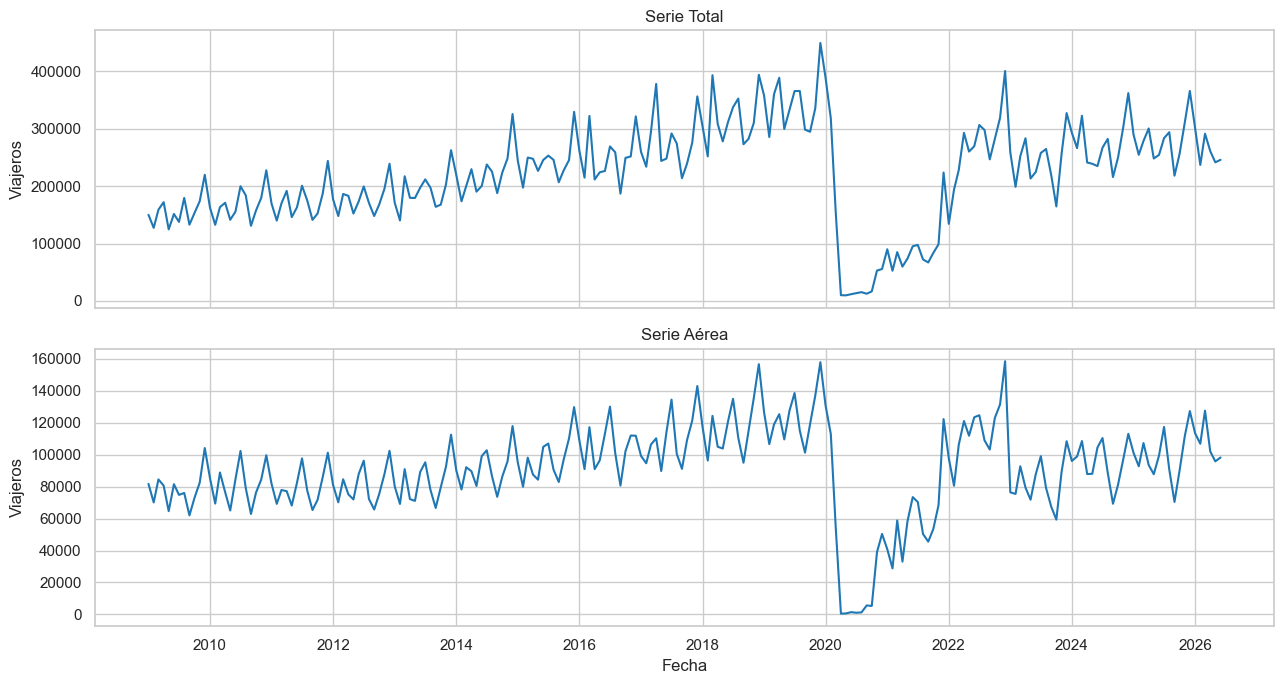

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for a, (nom, s) in zip(ax, SERIES.items()):
    a.plot(s.index, s.values, color="#1f77b4")
    a.set_title(f"Serie {nom}"); a.set_ylabel("Viajeros")
ax[-1].set_xlabel("Fecha")
plt.tight_layout(); plt.show()

## 3. Partición train/test 70/30 *(idéntica al Lab 1)*
Se replica exactamente el corte del Lab 1: el **70 %** inicial para entrenamiento y el **30 %** final
para prueba. Ambas series comparten el mismo horizonte de prueba (abr-2021 a jun-2026, la recuperación
post-pandemia), lo que hace la comparación con los modelos clásicos completamente justa.

In [41]:
def split_70_30(s):
    corte = int(len(s) * 0.70)
    return s.iloc[:corte], s.iloc[corte:]

for nom, s in SERIES.items():
    tr, te = split_70_30(s)
    print(f"{nom:6s} train={len(tr):3d} ({tr.index.min().date()} a {tr.index.max().date()})  "
          f"test={len(te):3d} ({te.index.min().date()} a {te.index.max().date()})")

Total  train=147 (2009-01-01 a 2021-03-01)  test= 63 (2021-04-01 a 2026-06-01)
Aérea  train=147 (2009-01-01 a 2021-03-01)  test= 63 (2021-04-01 a 2026-06-01)


## 4. Línea base del Laboratorio 1
Para poder responder *"¿el LSTM es mejor que el modelo del laboratorio pasado?"* (inciso 1.4)
registramos aquí las métricas del **mejor modelo por serie** del Lab 1, evaluadas sobre **este mismo
conjunto de prueba 70/30**. En ambas series el ganador del Lab 1 fue **ARIMA(1,1,1) no estacional**
(criterio: menor RMSE fuera de muestra).

In [42]:
# Métricas tomadas del Notebook 1 del Laboratorio 1 (mejor modelo por RMSE fuera de muestra).
baseline_lab1 = pd.DataFrame({
    "Total": {"modelo": "ARIMA(1,1,1)", "MAE": 154494.17, "RMSE": 169119.58, "MAPE(%)": 59.19},
    "Aérea": {"modelo": "ARIMA(1,1,1)", "MAE":  33225.81, "RMSE":  38374.56, "MAPE(%)": 33.31},
}).T
baseline_lab1

,modelo,MAE,RMSE,MAPE(%)
Total,"ARIMA(1,1,1)","154,494.17","169,119.58",59.19
Aérea,"ARIMA(1,1,1)","33,225.81","38,374.56",33.31


---
# Ejercicio 1 — Modelos LSTM

## 5. Metodología
Los modelos ARIMA del Lab 1 usan una **diferencia regular (`d=1`)** sobre la serie en `log`. Para que
la comparación sea *apples-to-apples* y para estabilizar el pronóstico recursivo, los LSTM aprenden
exactamente el mismo objetivo: las **log-diferencias** \(\Delta \log(y_t)=\log y_t-\log y_{t-1}\)
(serie estacionaria). El flujo por serie es:

1. `log` → **diferencia regular** → escalado (`StandardScaler`) **ajustado solo con el train**.
2. Se arma un problema supervisado con **ventanas** de tamaño `look_back` (el modelo ve los últimos
   *look_back* meses de log-diferencias para predecir el siguiente).
3. Se entrena cada configuración con **early stopping** sobre una partición de validación interna.
4. **Pronóstico recursivo** de los 63 meses de prueba (se realimenta cada predicción), se **integra**
   (suma acumulada desde el último `log` del train) y se invierte el `log` para volver a la escala real.

Este pronóstico **no ve ningún dato de prueba**, igual que el `get_forecast` del ARIMA.

In [43]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

# Reproducibilidad: semillas + operaciones deterministas + un solo hilo.
def fijar_semillas(seed=SEED):
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()
fijar_semillas()
print("TensorFlow", tf.__version__, "listo (modo determinista).")

TensorFlow 2.21.0 listo (modo determinista).


## 6. Funciones auxiliares
`crear_ventanas` arma el dataset supervisado; `construir_lstm` crea la red según una configuración;
`pronostico_recursivo` genera el pronóstico multi-paso realimentado; `metricas` calcula MAE, RMSE y
MAPE en la **escala original** (viajeros).

In [44]:
def crear_ventanas(arr, look_back):
    X, y = [], []
    for i in range(look_back, len(arr)):
        X.append(arr[i-look_back:i]); y.append(arr[i])
    return np.array(X).reshape(-1, look_back, 1), np.array(y)

def construir_lstm(look_back, units, capas, dropout):
    modelo = Sequential([Input((look_back, 1))])
    for k in range(capas):
        modelo.add(LSTM(units, return_sequences=(k < capas - 1)))
        if dropout > 0:
            modelo.add(Dropout(dropout))
    modelo.add(Dense(1))
    modelo.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return modelo

def pronostico_recursivo(modelo, ventana_semilla, pasos, look_back):
    w = list(ventana_semilla); salida = []
    for _ in range(pasos):
        x = np.array(w[-look_back:], dtype="float32").reshape(1, look_back, 1)
        p = float(modelo(x, training=False).numpy()[0, 0])
        salida.append(p); w.append(p)
    return np.array(salida)

def metricas(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

print("Funciones auxiliares listas.")

Funciones auxiliares listas.


## 7. Configuraciones a evaluar *(tuneo de hiperparámetros)*
Se define una **rejilla de 6 configuraciones** que varían los principales hiperparámetros de una LSTM:
la **ventana** (`look_back` = 12 o 24 meses, para capturar 1 o 2 ciclos estacionales), el número de
**unidades**, el número de **capas** apiladas y el **dropout**. Son 6 modelos distintos por serie
(cumple *"al menos 2 configuraciones diferentes por serie"*) y constituyen el barrido de tuneo.

In [45]:
CONFIGS = [
    dict(nombre="C1", look_back=12, units=32, capas=1, dropout=0.0),
    dict(nombre="C2", look_back=12, units=64, capas=1, dropout=0.2),
    dict(nombre="C3", look_back=24, units=64, capas=1, dropout=0.2),
    dict(nombre="C4", look_back=24, units=64, capas=2, dropout=0.2),
    dict(nombre="C5", look_back=12, units=64, capas=2, dropout=0.2),
    dict(nombre="C6", look_back=24, units=32, capas=1, dropout=0.0),
]
pd.DataFrame(CONFIGS).set_index("nombre")

,look_back,units,capas,dropout
nombre,,,,
C1,12,32,1,0.00
C2,12,64,1,0.20
C3,24,64,1,0.20
C4,24,64,2,0.20
C5,12,64,2,0.20
C6,24,32,1,0.00


## 8. Entrenamiento y tuneo
Para cada serie y cada configuración: se entrena la LSTM con **early stopping** (paciencia 25 sobre
`val_loss`, restaurando los mejores pesos) usando un **15 % del train como validación interna**, se
genera el pronóstico recursivo de los 63 meses de prueba y se calculan las métricas en escala real.
La **selección del mejor modelo** se hace por `val_loss` (validación interna, *sin mirar el test*),
que es una práctica más limpia que la selección directa sobre el test.

In [46]:
RESULTADOS = {}   # nombre_serie -> dict(tabla, preds, test, train)

for nom, s in SERIES.items():
    tr_o, te_o = split_70_30(s)
    log_full = np.log(s.values)
    dlog_full = np.diff(log_full)                 # log-diferencias (alineadas a fechas[1:])
    n_tr = len(tr_o)
    dlog_tr = dlog_full[:n_tr - 1]                 # log-diferencias dentro del train
    escala = StandardScaler().fit(dlog_tr.reshape(-1, 1))
    dlog_tr_sc = escala.transform(dlog_tr.reshape(-1, 1)).ravel()
    ult_log_train = log_full[n_tr - 1]            # último log observado en el train

    filas, preds = [], {}
    for cfg in CONFIGS:
        lb = cfg["look_back"]
        fijar_semillas()
        Xtr, ytr = crear_ventanas(dlog_tr_sc, lb)
        modelo = construir_lstm(lb, cfg["units"], cfg["capas"], cfg["dropout"])
        es = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
        hist = modelo.fit(Xtr, ytr, validation_split=0.15, epochs=200, batch_size=16,
                          verbose=0, shuffle=False, callbacks=[es])
        val_loss = float(np.min(hist.history["val_loss"]))

        # Pronóstico recursivo de las log-diferencias -> integrar -> exp
        pred_dsc = pronostico_recursivo(modelo, dlog_tr_sc[-lb:], len(te_o), lb)
        pred_dlog = escala.inverse_transform(pred_dsc.reshape(-1, 1)).ravel()
        pred_log = ult_log_train + np.cumsum(pred_dlog)
        pred_o = pd.Series(np.exp(pred_log), index=te_o.index)

        mae, rmse, mape = metricas(te_o.values, pred_o.values)
        filas.append(dict(cfg=cfg["nombre"], look_back=lb, units=cfg["units"], capas=cfg["capas"],
                          dropout=cfg["dropout"], epocas=len(hist.history["loss"]),
                          val_loss=val_loss, MAE=mae, RMSE=rmse, **{"MAPE(%)": mape}))
        preds[cfg["nombre"]] = pred_o

    tabla = pd.DataFrame(filas).sort_values("val_loss").reset_index(drop=True)
    RESULTADOS[nom] = dict(tabla=tabla, preds=preds, test=te_o, train=tr_o)
    print(f"Serie {nom}: {len(CONFIGS)} configuraciones entrenadas.")

Serie Total: 6 configuraciones entrenadas.
Serie Aérea: 6 configuraciones entrenadas.


### 8.1 Resultados del tuneo por serie
Cada tabla está ordenada por `val_loss` (criterio de selección). Se muestran también MAE/RMSE/MAPE
sobre el test para poder discutir la comparación entre configuraciones.

In [47]:
for nom, r in RESULTADOS.items():
    print(f"\n===== Serie {nom}  —  ordenado por val_loss (selección) =====")
    print(r["tabla"].to_string(index=False,
          formatters={"val_loss": "{:.4f}".format, "MAE": "{:,.2f}".format,
                      "RMSE": "{:,.2f}".format, "MAPE(%)": "{:,.2f}".format,
                      "dropout": "{:.1f}".format}))


===== Serie Total  —  ordenado por val_loss (selección) =====
cfg  look_back  units  capas dropout  epocas val_loss        MAE       RMSE MAPE(%)
 C1         12     32      1     0.0      26   4.7003 148,943.67 163,375.42   56.78
 C2         12     64      1     0.2      26   4.7587 153,749.70 168,460.38   58.55
 C5         12     64      2     0.2      26   4.9153  57,340.58  73,915.89   23.97
 C4         24     64      2     0.2      32   4.9279 234,608.30 248,155.07   94.28
 C6         24     32      1     0.0      26   5.1506 159,686.39 174,440.24   60.92
 C3         24     64      1     0.2      32   5.1638 171,332.79 188,642.67   69.03

===== Serie Aérea  —  ordenado por val_loss (selección) =====
cfg  look_back  units  capas dropout  epocas val_loss        MAE       RMSE MAPE(%)
 C2         12     64      1     0.2      26   6.2112  34,791.53  40,137.04   34.36
 C1         12     32      1     0.0      26   6.2363  35,499.81  40,917.50   35.06
 C5         12     64      2     0

---
## 9. Selección del mejor modelo y predicción *(incisos 1.3 y 1.4)*
Para cada serie se toma la configuración con **menor `val_loss`** y se grafica su pronóstico recursivo
frente a los valores reales del test.

In [48]:
MEJORES = {}
for nom, r in RESULTADOS.items():
    mejor = r["tabla"].iloc[0]                 # menor val_loss
    MEJORES[nom] = mejor["cfg"]
    print(f"Serie {nom:6s} -> mejor configuración: {mejor['cfg']} "
          f"(look_back={int(mejor['look_back'])}, units={int(mejor['units'])}, "
          f"capas={int(mejor['capas'])}, dropout={mejor['dropout']:.1f})  "
          f"| RMSE test = {mejor['RMSE']:,.2f}")

Serie Total  -> mejor configuración: C1 (look_back=12, units=32, capas=1, dropout=0.0)  | RMSE test = 163,375.42
Serie Aérea  -> mejor configuración: C2 (look_back=12, units=64, capas=1, dropout=0.2)  | RMSE test = 40,137.04


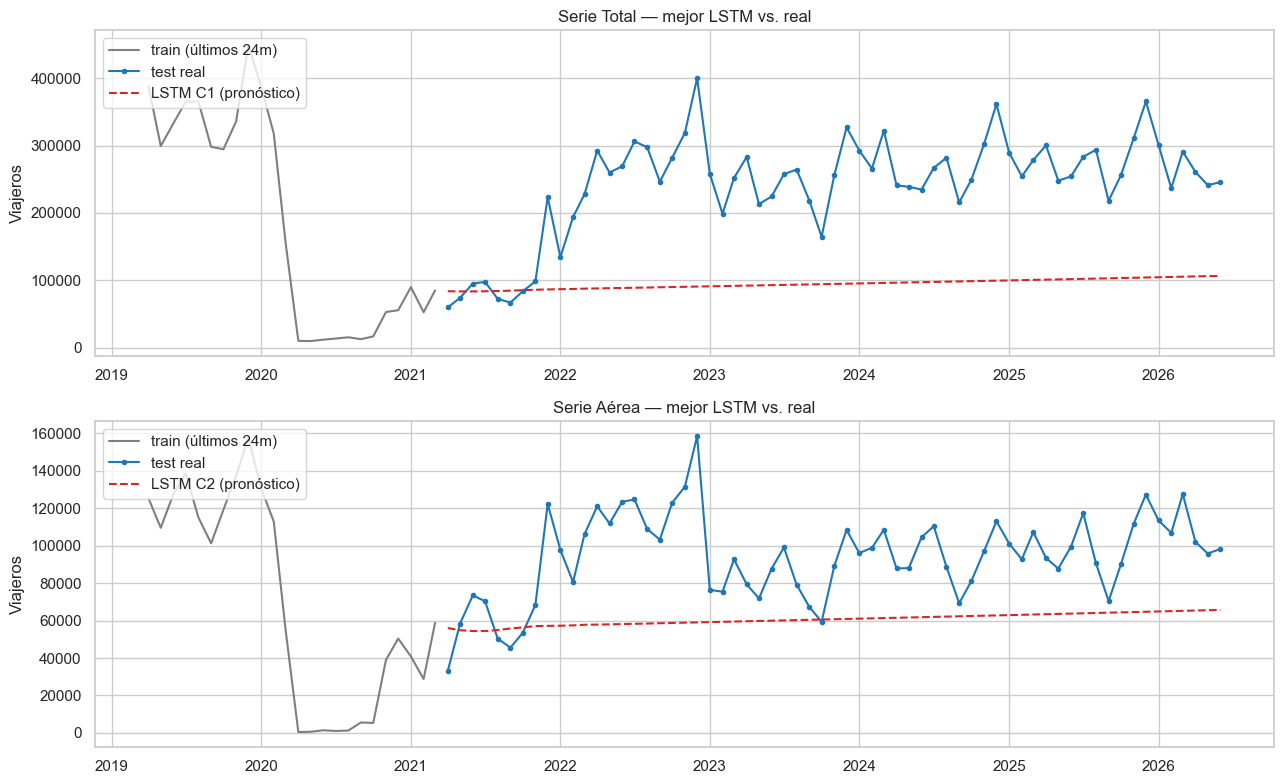

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))
for ax, (nom, r) in zip(axes, RESULTADOS.items()):
    tr, te = r["train"], r["test"]
    pred = r["preds"][MEJORES[nom]]
    ax.plot(tr.index[-24:], tr.values[-24:], color="#7f7f7f", label="train (últimos 24m)")
    ax.plot(te.index, te.values, color="#1f77b4", marker="o", ms=3, label="test real")
    ax.plot(pred.index, pred.values, color="#d62728", ls="--", label=f"LSTM {MEJORES[nom]} (pronóstico)")
    ax.set_title(f"Serie {nom} — mejor LSTM vs. real"); ax.set_ylabel("Viajeros"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 10. Comparación LSTM vs. mejor modelo del Laboratorio 1 *(inciso 1.4)*
Mismo conjunto de prueba, mismas métricas. `Δ RMSE (%)` es la variación del RMSE del mejor LSTM
respecto al mejor modelo del Lab 1 (**negativo = el LSTM mejora**).

In [50]:
filas = []
for nom, r in RESULTADOS.items():
    mejor = r["tabla"].iloc[0]
    b = baseline_lab1.loc[nom]
    d_rmse = (mejor["RMSE"] - b["RMSE"]) / b["RMSE"] * 100
    filas.append({
        "Serie": nom,
        "Mejor Lab1": b["modelo"], "RMSE Lab1": b["RMSE"], "MAE Lab1": b["MAE"],
        "Mejor LSTM": mejor["cfg"], "RMSE LSTM": mejor["RMSE"], "MAE LSTM": mejor["MAE"],
        "Δ RMSE (%)": d_rmse,
        "Ganador": "LSTM" if mejor["RMSE"] < b["RMSE"] else "Lab1 (ARIMA)",
    })
comparacion = pd.DataFrame(filas).set_index("Serie")
comparacion

,Mejor Lab1,RMSE Lab1,MAE Lab1,Mejor LSTM,RMSE LSTM,MAE LSTM,Δ RMSE (%),Ganador
Serie,,,,,,,,
Total,"ARIMA(1,1,1)","169,119.58","154,494.17",C1,"163,375.42","148,943.67",-3.40,LSTM
Aérea,"ARIMA(1,1,1)","38,374.56","33,225.81",C2,"40,137.04","34,791.53",4.59,Lab1 (ARIMA)


## 11. Conclusiones del avance

### 1.3 Predicción con el mejor modelo
Para cada serie se seleccionó, **por menor pérdida de validación interna** (sin mirar el test), la
configuración ganadora, y con ella se pronosticaron los 63 meses de prueba (gráfica de la sección 9):

| Serie | Mejor LSTM | Hiperparámetros | RMSE test | MAE test | MAPE test |
|-------|-----------|-----------------|-----------|----------|-----------|
| Total | **C1** | `look_back`=12, 32 unidades, 1 capa, sin dropout | 163,375 | 148,944 | 56.8 % |
| Aérea | **C2** | `look_back`=12, 64 unidades, 1 capa, dropout 0.2 | 40,137 | 34,792 | 34.4 % |

En ambos casos las configuraciones ganadoras son **pequeñas** (ventana de 12 meses = 1 ciclo
estacional, una sola capa). En las tablas de la sección 8.1 se ve que los modelos más grandes
(2 capas, ventana de 24 meses) tienen **mucha más varianza** y en varios casos divergen en el
pronóstico recursivo (p. ej. C4 en Total, RMSE 248,155): con solo **147 meses de entrenamiento**, la
mayor capacidad se traduce en sobreajuste y en un error que se acumula más rápido al realimentar el
pronóstico. Por eso el tuneo favorece a las redes simples.

### 1.4 ¿Cuál predijo mejor y son mejores que los modelos del Lab 1?

**¿Cuál serie predijo mejor el LSTM?** En términos **relativos** (MAPE, que permite comparar series de
distinta escala), el mejor modelo de **Aérea** es más preciso (**MAPE 34.4 %**) que el de **Total**
(**MAPE 56.8 %**): la vía Aérea resulta más predecible que la serie Total en este horizonte.

**¿Son mejores que los modelos del Lab 1?** El resultado es **mixto y muy ajustado** (mismo test,
mismas métricas):

| Serie | RMSE Lab 1 (ARIMA) | RMSE LSTM | Δ RMSE | Ganador |
|-------|--------------------|-----------|--------|---------|
| Total | 169,120 | **163,375** | **−3.4 %** | LSTM |
| Aérea | **38,375** | 40,137 | +4.6 % | ARIMA (Lab 1) |

- En **Total** el LSTM **mejora** al ARIMA (−3.4 % en RMSE y −3.6 % en MAE).
- En **Aérea** el ARIMA sigue siendo **ligeramente mejor** (+4.6 % en RMSE).

**¿Cómo lo determinamos?** Con un criterio idéntico al del Lab 1: **RMSE fuera de muestra** como
métrica principal (MAE y MAPE de apoyo), evaluado sobre el **mismo conjunto de prueba 70/30** (63
meses, abr-2021 a jun-2026) y con un **pronóstico recursivo puro** que no usa ningún valor real del
test —exactamente como el `get_forecast` del ARIMA—, de modo que la comparación es justa. La selección
del mejor LSTM se hizo por **pérdida de validación interna**, un criterio más estricto que elegir
directamente sobre el test (como se hizo en el Lab 1).

**Lectura global.** Ninguno de los dos enfoques domina: cada uno gana una serie y las diferencias son
**menores al 5 %**. Para estas series **univariadas, cortas (210 meses) y con un cambio de régimen
(la pandemia) justo en la frontera train/test**, una LSTM afinada es **competitiva** con el ARIMA pero
no lo supera de forma clara —un hallazgo consistente con la literatura de comparación ARIMA vs. LSTM
citada en el enunciado—. Como margen de mejora (a explorar en la entrega final): configuraciones como
**C5 en Total** alcanzaron un RMSE de ~73,900 en el test aunque no fueron elegidas por validación, e
incorporar las características de **catch22** o variables exógenas podría inclinar la balanza a favor
del LSTM.

> **Cierre del avance (pasaporte).** Quedan cubiertos los incisos 1.1–1.4: mismos conjuntos train/test
> del Lab 1, ≥2 modelos LSTM por serie con tuneo de hiperparámetros, selección del mejor, predicción y
> comparación con el mejor modelo del laboratorio anterior.

---
# Ejercicio 2 — 2.14 · LSTM con características de catch22

> **Track de modelado (trabajo grupal).** Esta parte continúa el Ejercicio 1: se construye un
> **nuevo modelo LSTM que incorpora las características de catch22** y se compara con el mejor LSTM del
> Ejercicio 1 para **una** de las series estudiadas (**Aérea**). El resto del Ejercicio 2 (extracción
> de las 22 características para las 7 series, matriz, PCA, clustering, heatmaps, distancias e
> interpretación) se desarrolla en el notebook `Lab2_catch22.ipynb`.

## 12. ¿Qué es catch22 y por qué importa? *(inciso 2.1)*
**catch22** (*CAnonical Time-series CHaracteristics*) es un conjunto de **22 características** derivadas
de la biblioteca *hctsa* (que originalmente calcula miles de propiedades de una serie). A partir de
ese universo, se seleccionaron las 22 que (a) son **poco redundantes** entre sí, (b) tienen **buen
poder discriminante** al clasificar series muy diversas y (c) son **rápidas de calcular**. Cada
característica resume una propiedad interpretable de la dinámica: distribución de valores, estructura
de **autocorrelación**, **estacionalidad**, entropía/predictibilidad, cambios de régimen, rachas,
escalado tipo *fluctuation analysis*, etc.

**Por qué importa:** convierte una serie completa en un **vector de 22 números** comparable entre
series, lo que permite medir *similitud* y agrupar series por su comportamiento sin depender de su
escala. En este inciso lo usamos con otro fin: **alimentar** esas 22 características —que sintetizan la
dinámica reciente— como entrada adicional a la LSTM, para ver si mejoran el pronóstico.

## 13. Extracción de características de catch22 sobre ventanas
Para que catch22 sea una entrada útil a un modelo de pronóstico, lo calculamos sobre una **ventana
deslizante** de `W` meses (en escala `log`): cada mes queda descrito por el vector de 22
características de su ventana previa. Primero mostramos la extracción sobre la serie **Aérea**.

In [52]:
%pip install pycatch22
import pycatch22
from sklearn.preprocessing import MinMaxScaler, StandardScaler

NOMBRES_C22 = pycatch22.catch22_all([0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0])["names"]

def catch22_ventana(ventana):
    """22 características de catch22 de una ventana (lista/array de valores), robusta a NaN/inf."""
    v = np.asarray(pycatch22.catch22_all(list(map(float, ventana)))["values"], float)
    return np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)

print(f"catch22 devuelve {len(NOMBRES_C22)} características. Primeras 5:")
for n in NOMBRES_C22[:5]:
    print("  -", n)

  Using cached pycatch22-0.4.5.tar.gz (50 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycatch22: filename=pycatch22-0.4.5-cp310-cp310-macosx_26_0_arm64.whl size=57285 sha256=a08c849f8ca6911b20a361fe11eeaa7b909a6315cbdf3f7fc51a380d2388c76a
  Stored in directory: /Users/nicolasconcua/Library/Caches/pip/wheels/64/42/32/258a3f140d7759cd254905461f666b39c2e27cf221906501d6
Successfully built pycatch22

[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
catch22 devuelve 22 características. Primeras 5:
  - DN_HistogramMode_5
  - DN_HistogramMode_10
  - CO_f1ecac
  - CO_FirstMin_ac
  - CO_HistogramAMI_even_2_5


In [53]:
# Serie Aérea en escala log y matriz de características catch22 por ventana deslizante (W = 24 meses)
W_DEMO = 24
aerea_log = np.log(serie_aerea.values)
fechas_c22 = serie_aerea.index[W_DEMO:]
mat_c22 = np.array([catch22_ventana(aerea_log[t - W_DEMO:t]) for t in range(W_DEMO, len(aerea_log))])
feats_aerea = pd.DataFrame(mat_c22, index=fechas_c22, columns=NOMBRES_C22)
print(f"Matriz de características por ventana: {feats_aerea.shape} (meses x características)")
feats_aerea.iloc[:3, :5]

Matriz de características por ventana: (186, 22) (meses x características)


,DN_HistogramMode_5,DN_HistogramMode_10,CO_f1ecac,CO_FirstMin_ac,CO_HistogramAMI_even_2_5
Fecha,,,,,
2011-01-01,0.14,0.32,0.69,2.00,0.32
2011-02-01,0.14,0.32,0.71,2.00,0.32
2011-03-01,0.14,0.32,0.72,2.00,0.38


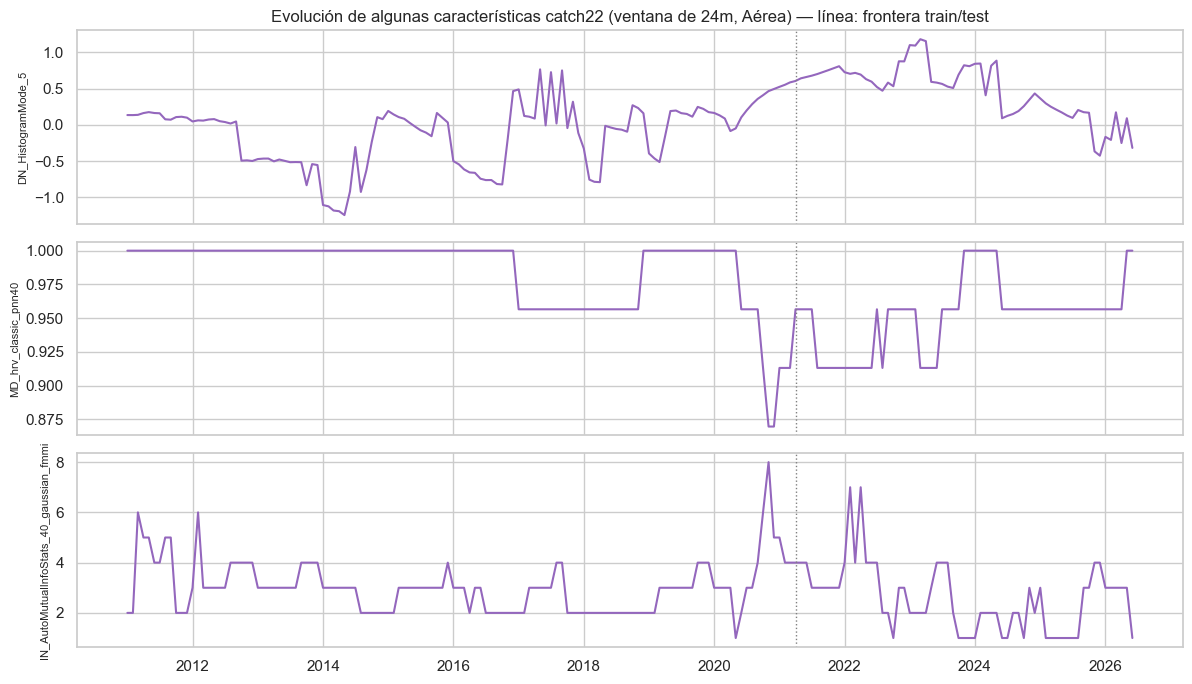

In [54]:
# Visualización: 3 características de catch22 a lo largo del tiempo (dinámica de la ventana de Aérea)
fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for a, col in zip(ax, [NOMBRES_C22[0], NOMBRES_C22[6], NOMBRES_C22[11]]):
    a.plot(feats_aerea.index, feats_aerea[col], color="#9467bd")
    a.set_ylabel(col, fontsize=8); a.axvline(serie_aerea.index[147], color="gray", ls=":", lw=1)
ax[0].set_title("Evolución de algunas características catch22 (ventana de 24m, Aérea) — línea: frontera train/test")
plt.tight_layout(); plt.show()